In [2]:
# exemple de feature extraction from an image

In [3]:
import numpy as np
from scipy.signal import convolve2d
from skimage import data, color
from skimage.transform import resize

import matplotlib.pyplot as plt

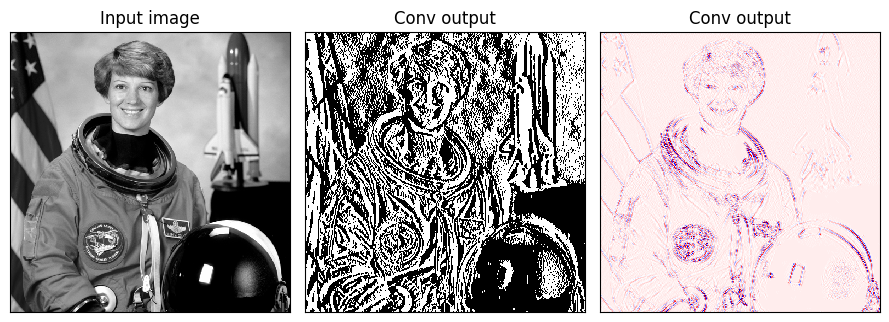

In [ ]:
# apply a convolution (a filter)

# 1) load a real input image, grayscale
image = color.rgb2gray(data.astronaut())

# 2) define a first conv for edge extraction
kernelEdges = np.array([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
], dtype=float)

kernelBlobs = np.array([
    [0., -1., 0.],
    [-1., 4., -1.],
    [0., -1., 0.]
], dtype=float)

kernelTexture = np.array([    
    [ -4., -4., -4. ],
    [ -4.,  32., -4. ],
    [ -4., -4., -4. ]
], dtype=float)

kernelCorner = np.array([    
    [ 2., -1., -1. ],
    [ -1.,  2., -1. ],
    [ -1., -1., 2. ]
], dtype=float)


kernel = kernelEdges  # choose which kernel to apply
# 3) apply convolution (valid padding)
output1 = convolve2d(image, kernelEdges, mode='valid')
output2 = convolve2d(output1, kernelCorner, mode='valid')

# 4) visualize input, kernel, output  
fig, axes = plt.subplots(1, 3, figsize=(9, 12))

axes[0].imshow(image, cmap='gray', interpolation='nearest')
axes[0].set_title("Input image")

binary_output = (output1 > 0).astype(np.uint8)  # or use another threshold
axes[1].imshow(binary_output, cmap='gray', interpolation='nearest')
axes[1].set_title("Conv output")

axes[2].imshow(output2, cmap='seismic', interpolation='nearest')
axes[2].set_title("Conv output")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

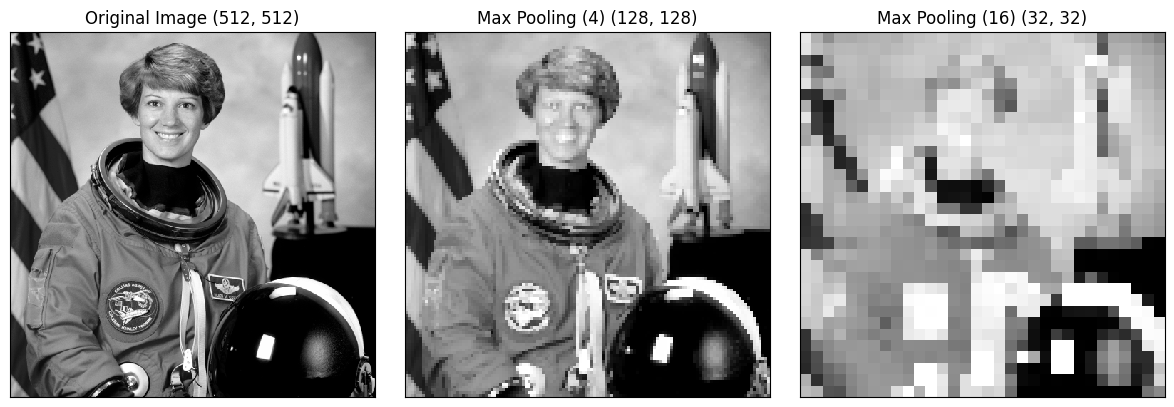

In [9]:
# apply a pooling operation

from scipy.ndimage import maximum_filter

# Apply different pooling operations
max_pool4 = maximum_filter(image, size=4)
max_pool16 = maximum_filter(image, size=16)

max_pooled_strided4 = max_pool4[::4, ::4]
max_pooled_strided16 = max_pool16[::16, ::16]

# Visualize original and pooled images
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(image, cmap='gray', interpolation='nearest')
axes[0].set_title(f"Original Image {image.shape}")

axes[1].imshow(max_pooled_strided4, cmap='gray', interpolation='nearest')
axes[1].set_title(f"Max Pooling (4) {max_pooled_strided4.shape}")

axes[2].imshow(max_pooled_strided16, cmap='gray', interpolation='nearest')
axes[2].set_title(f"Max Pooling (16) {max_pooled_strided16.shape}")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
